# **1. Perkenalan Dataset**


Dataset yang digunakan pada eksperimen kali ini adalah dataset review aplikasi mobile Line Bank. Dataset ini digunakan sebagai bahan eksperimen analisis sentimen terhadap aplikasi tersebut.

1. **Sumber Dataset**:  
   Dataset ini didapat dari hasil scrapping aplikasi Line Bank pada market Aplikasi Google Playstore menggunakan google-play-scraper.

2. **Jumlah Data**:

   Jumlah data pada dataset ini yaitu berjumlah 4000


# **2. Import Library**

In [20]:
!pip install google-play-scraper
import pandas as pd
import time
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

# **3. Memuat Dataset**

In [21]:
# Scrapping Dataset
from google_play_scraper import reviews, Sort

scrapreview = []
token = None

while len(scrapreview) < 4000:
    data, token = reviews(
        'id.co.linebank',
        lang='id',
        country='id',
        sort=Sort.MOST_RELEVANT,
        count=200,
        continuation_token=token
    )

    scrapreview.extend(data)

    if not token:
        break

    time.sleep(0.5)

app_reviews_df = pd.DataFrame(scrapreview[:4000])

print(
    "Total sampel data ulasan Line Bank yang didapat:",
    app_reviews_df.shape[0]
)

Total sampel data ulasan Line Bank yang didapat: 4000


In [22]:
# Menyimpan seluruh hasil scraping ke CSV
app_reviews_df.to_csv(
    'linebank_reviews_raw.csv',
    index=False
)

print(
    "Dataset berhasil disimpan:",
    app_reviews_df.shape
)

Dataset berhasil disimpan: (4000, 11)


In [23]:
app_reviews_df = pd.DataFrame(scrapreview[:4000])

app_reviews_df.to_csv(
    'linebank_reviews_raw.csv',
    index=False
)

print(app_reviews_df.columns)

Index(['reviewId', 'userName', 'userImage', 'content', 'score',
       'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent',
       'repliedAt', 'appVersion'],
      dtype='object')


In [24]:
# Menampilkan lima baris pertama
app_reviews_df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,6435f401-e35e-472e-bbf1-fcf859f34801,Rans,https://play-lh.googleusercontent.com/a/ACg8oc...,Program dan internalnya lebih memadai di pakai...,5,3,2.4.10,2026-06-22 13:44:49,None,NaT,2.4.10
1,0974fc7f-f2b2-4091-b328-ca98633123d8,Aditya Wicaksono,https://play-lh.googleusercontent.com/a/ACg8oc...,"Untuk versi yang sekarang bagus UI-nya, tetap ...",5,18,2.4.5,2026-04-15 00:38:26,None,NaT,2.4.5
2,2c82aa49-43f5-4b12-86c3-7778a6ad6287,R G,https://play-lh.googleusercontent.com/a-/ALV-U...,"aduuuh gmn dong, udah buka rekening, dah pakai...",1,4,2.4.10,2026-06-11 10:15:56,Hi Sobat LINE Bank! Mohon maaf atas ketidaknya...,2026-06-11 10:03:09,2.4.10
3,369d6e86-3b63-4e04-986c-6d13f592c6e5,rayhan azzikri,https://play-lh.googleusercontent.com/a-/ALV-U...,"Saya kesulitan login hingga Beberapa kali, cha...",2,3,2.4.9,2026-06-04 14:26:29,Hi Sobat LINE Bank! Mohon maaf atas ketidaknya...,2026-06-05 07:35:21,2.4.9
4,6b691b81-780a-4512-bc68-71aaceead2a7,Afifah Firdayansyah,https://play-lh.googleusercontent.com/a-/ALV-U...,Perbaikin dong applikasinya lemot bgttt bahkan...,2,4,2.4.10,2026-06-13 07:07:58,Hi Sobat LINE Bank! Mohon maaf atas ketidaknya...,2026-06-15 10:47:46,2.4.10


# **4. Exploratory Data Analysis (EDA)**

In [25]:
# Informasi Dataset
app_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              4000 non-null   object        
 1   userName              4000 non-null   object        
 2   userImage             4000 non-null   object        
 3   content               4000 non-null   object        
 4   score                 4000 non-null   int64         
 5   thumbsUpCount         4000 non-null   int64         
 6   reviewCreatedVersion  3048 non-null   object        
 7   at                    4000 non-null   datetime64[ns]
 8   replyContent          2233 non-null   object        
 9   repliedAt             2233 non-null   datetime64[ns]
 10  appVersion            3048 non-null   object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 343.9+ KB


In [26]:
# Statistik Deskriptif
app_reviews_df.describe()

,score,thumbsUpCount,at,repliedAt
count,4000.000000,4000.000000,4000,2233
mean,2.525500,8.646000,2023-02-12 18:21:00.250500096,2023-04-20 15:28:34.503358720
min,1.000000,0.000000,2021-06-10 02:07:51,2021-06-10 04:51:37
25%,1.000000,0.000000,2021-12-24 04:45:26,2021-12-09 15:46:51
50%,2.000000,1.000000,2022-09-26 03:38:44,2023-06-13 12:04:44
75%,5.000000,4.000000,2023-12-19 08:44:19.500000,2024-06-10 10:08:11
max,5.000000,1113.000000,2026-07-02 22:17:02,2026-07-03 01:15:01
std,1.697961,37.455639,NaN,NaN


In [27]:
# Missing Value
app_reviews_df.isnull().sum()

,0
reviewId,0
userName,0
userImage,0
content,0
score,0
thumbsUpCount,0
reviewCreatedVersion,952
at,0
replyContent,1767
repliedAt,1767


In [28]:
# Duplicate
app_reviews_df.duplicated().sum()

np.int64(0)

In [29]:
# Distribusi Rating
app_reviews_df['score'].value_counts()

,count
score,
1,1914
5,1024
2,398
3,384
4,280


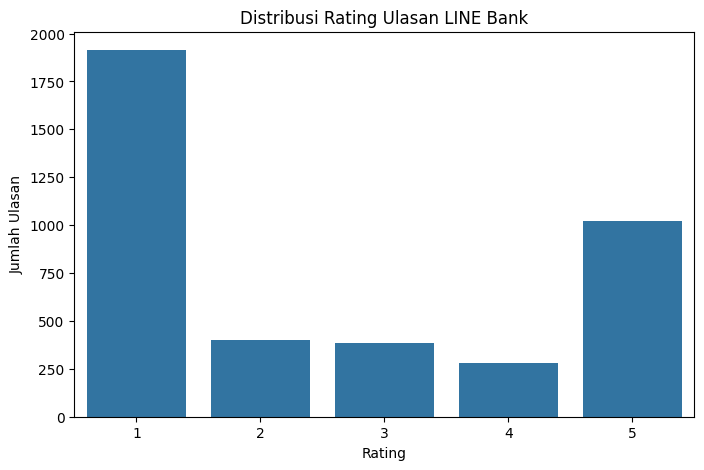

In [30]:
# Visualisasi Distribusi Rating

plt.figure(figsize=(8,5))

sns.countplot(
    x='score',
    data=app_reviews_df
)

plt.title('Distribusi Rating Ulasan LINE Bank')
plt.xlabel('Rating')
plt.ylabel('Jumlah Ulasan')

plt.show()

# **5. Data Preprocessing**

In [31]:
# Memilih kolom yang digunakan
df = app_reviews_df[['content', 'score']]

# Mengecek missing value kembali
df.isnull().sum()

,0
content,0
score,0


In [32]:
# Menghapus data duplikat
df = df.drop_duplicates()

print(
    "Jumlah data setelah menghapus duplikat:",
    df.shape[0]
)

Jumlah data setelah menghapus duplikat: 4000


In [33]:
# Mengubah nama kolom
df.columns = [
    'review',
    'rating'
]

df.head()

,review,rating
0,Program dan internalnya lebih memadai di pakai...,5
1,"Untuk versi yang sekarang bagus UI-nya, tetap ...",5
2,"aduuuh gmn dong, udah buka rekening, dah pakai...",1
3,"Saya kesulitan login hingga Beberapa kali, cha...",2
4,Perbaikin dong applikasinya lemot bgttt bahkan...,2


In [34]:
def sentiment(score):
    if score >= 4:
        return 'positive'
    elif score == 3:
        return 'neutral'
    else:
        return 'negative'

df['sentiment'] = df['rating'].apply(sentiment)

In [35]:
# Distribusi sentimen
df['sentiment'].value_counts()

,count
sentiment,
negative,2312
positive,1304
neutral,384


In [36]:
# Melihat hasil labeling
df.head()

,review,rating,sentiment
0,Program dan internalnya lebih memadai di pakai...,5,positive
1,"Untuk versi yang sekarang bagus UI-nya, tetap ...",5,positive
2,"aduuuh gmn dong, udah buka rekening, dah pakai...",1,negative
3,"Saya kesulitan login hingga Beberapa kali, cha...",2,negative
4,Perbaikin dong applikasinya lemot bgttt bahkan...,2,negative


In [37]:
# Mengubah teks menjadi huruf kecil (Case folding)
df['review'] = df['review'].astype(str).str.lower()

In [38]:
# Remove Mention
df['review'] = df['review'].apply(
    lambda x: re.sub(r'@[A-Za-z0-9_]+', '', x)
)

# Remove Hashtag
df['review'] = df['review'].apply(
    lambda x: re.sub(r'#[A-Za-z0-9_]+', '', x)
)

# Remove RT
df['review'] = df['review'].apply(
    lambda x: re.sub(r'RT[\s]+', '', x)
)

# Remove URL
import re

df['review'] = df['review'].apply(
    lambda x: re.sub(r'http\S+|www\S+', '', x)
)

#Remove Number
df['review'] = df['review'].str.replace(
    r'\d+',
    '',
    regex=True
)

# Remove Punctuation
import string

df['review'] = df['review'].apply(
    lambda x: x.translate(
        str.maketrans('', '', string.punctuation)
    )
)

# Remove Extra Spaces
df['review'] = df['review'].apply(
    lambda x: ' '.join(x.split())
)

df.head()

,review,rating,sentiment
0,program dan internalnya lebih memadai di pakai...,5,positive
1,untuk versi yang sekarang bagus uinya tetap si...,5,positive
2,aduuuh gmn dong udah buka rekening dah pakai d...,1,negative
3,saya kesulitan login hingga beberapa kali chat...,2,negative
4,perbaikin dong applikasinya lemot bgttt bahkan...,2,negative


In [39]:
# Hasil
df[['review', 'sentiment']].head()

,review,sentiment
0,program dan internalnya lebih memadai di pakai...,positive
1,untuk versi yang sekarang bagus uinya tetap si...,positive
2,aduuuh gmn dong udah buka rekening dah pakai d...,negative
3,saya kesulitan login hingga beberapa kali chat...,negative
4,perbaikin dong applikasinya lemot bgttt bahkan...,negative


In [40]:
# Simpan Dataset
df.to_csv(
    'linebank_reviews_preprocessed.csv',
    index=False
)

print(
    "Dataset preprocessing berhasil disimpan"
)

Dataset preprocessing berhasil disimpan
